# Ferramentas

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


# Carregar o Conjunto de Dados

In [2]:
# Carregando o dataset MNIST
mnist = keras.datasets.mnist

# Dividindo os dados em conjuntos de treino e de teste
# train_images e test_images são as imagens
# train_labels e test_labels são os rótulos (o número correto de cada imagem)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Explorar e Pré-processar os Dados

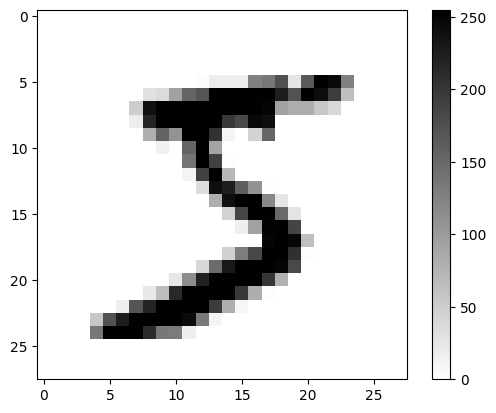

O rótulo da primeira imagem é: 5


In [3]:
# Acessando a Primeira Imagem de Treino
plt.figure()
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

print(f"O rótulo da primeira imagem é: {train_labels[0]}")

# Normalizando os dados
# As redes neurais funcionam melhor com números pequenos (entre 0 e 1).
# Os pixels das imagens vão de 0 a 255. Vamos dividir tudo por 255.
train_images = train_images / 255.0
test_images = test_images / 255.0

# Construir o Modelo de Deep Learning

Aqui é onde criamos a **"mente"** do nosso programa. Vamos empilhar **camadas de neurônios** para formar nossa rede.



In [4]:
# Criando a arquitetura da nossa rede neural
model = keras.Sequential([
    # 1. Camada de "Achatamento" (Flatten)
    # Transforma a imagem (que é uma matriz de 28x28 pixels) em uma única linha de 784 pixels.
    keras.layers.Flatten(input_shape=(28, 28)),

    # 2. Primeira Camada Densa (Dense)
    # É uma camada de neurônios totalmente conectados. Terá 128 neurônios.
    # A função de ativação 'relu' ajuda a rede a aprender padrões complexos.
    keras.layers.Dense(128, activation='relu'),

    # 3. Camada de Saída (Output Layer)
    # Tem 10 neurônios, um para cada dígito (0, 1, 2, ..., 9).
    # A função 'softmax' transforma a saída em probabilidades, nos dizendo qual neurônio
    # (e, portanto, qual dígito) tem a maior chance de ser o correto.
    keras.layers.Dense(10, activation='softmax')
])

# Mostra um resumo da arquitetura que criamos
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Compilar e Treinar o Modelo

In [5]:
# Compilando o modelo
model.compile(optimizer='adam',  # 'adam' é um otimizador eficiente e muito popular
              loss='sparse_categorical_crossentropy',  # Mede o quão errado o modelo está
              metrics=['accuracy'])  # Queremos monitorar a acurácia durante o treino

# Treinando o modelo!
# O modelo vai "olhar" para todas as imagens de treino 10 vezes (10 épocas).
print("\nIniciando o treinamento...")
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))
print("Treinamento concluído!")


Iniciando o treinamento...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8803 - loss: 0.4321 - val_accuracy: 0.9574 - val_loss: 0.1391
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9642 - loss: 0.1190 - val_accuracy: 0.9709 - val_loss: 0.0985
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9771 - loss: 0.0757 - val_accuracy: 0.9745 - val_loss: 0.0875
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9833 - loss: 0.0565 - val_accuracy: 0.9738 - val_loss: 0.0854
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9873 - loss: 0.0424 - val_accuracy: 0.9761 - val_loss: 0.0767
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9898 - loss: 0.0338 - val_accuracy: 0.9753 - val_loss: 0.0826
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9915 - loss: 0.0275 - val_accuracy: 0.9778 - val_loss: 0.0813
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - acc

# Avaliar o Desempenho e Fazer Previsões

313/313 - 1s - 2ms/step - accuracy: 0.9784 - loss: 0.0786

Acurácia no conjunto de teste: 0.9784
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


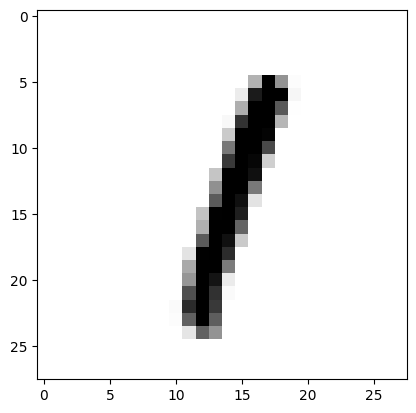

O modelo previu que este número é: 1
O número correto é: 1


In [6]:
# Avaliando a acurácia final com os dados de teste
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nAcurácia no conjunto de teste: {test_acc:.4f}')

# Fazendo previsões para todo o conjunto de teste
predictions = model.predict(test_images)

# Vamos testar uma única imagem (a de índice 5, por exemplo)
image_index = 5
plt.imshow(test_images[image_index], cmap=plt.cm.binary)
plt.show()

# A previsão é um array de 10 probabilidades. O maior valor é a aposta do modelo.
predicted_label = np.argmax(predictions[image_index])
true_label = test_labels[image_index]

print(f"O modelo previu que este número é: {predicted_label}")
print(f"O número correto é: {true_label}")

# Fazer o Upload da Imagem

In [7]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Abre a janela para fazer upload do arquivo
uploaded = files.upload()

# Pega o nome do arquivo que você enviou
for fn in uploaded.keys():
  print(f'Você enviou o arquivo "{fn}" com {len(uploaded[fn])} bytes')
  path = fn

Saving Meu_Numero.png to Meu_Numero (2).png
Você enviou o arquivo "Meu_Numero (2).png" com 1512 bytes


# Carregar, Processar e Preparar a Imagem

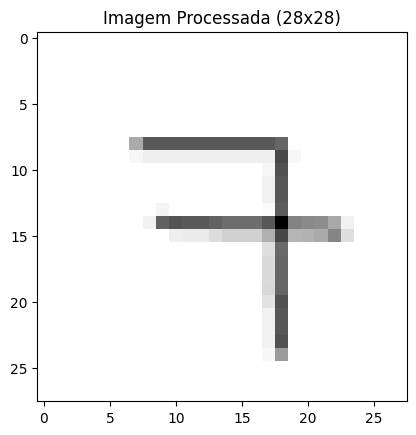

In [18]:
# Abre a imagem usando a biblioteca PIL (Pillow)
img = Image.open(path)

# 1. Converte para tons de cinza ('L' de luminosidade)
img_gray = img.convert('L')

# 2. Inverte as cores (IMPORTANTE!)
# O modelo treinou com dígito branco em fundo preto. No Paint, fizemos o contrário.
img_inverted = ImageOps.invert(img_gray)

# 3. Redimensiona para 28x28 pixels
img_resized = img_inverted.resize((28, 28))

# Converte a imagem para um array numpy
img_array = np.array(img_resized)

# 4. Normaliza os pixels (divide por 255)
img_normalized = img_array / 255.0

# 5. Adiciona uma dimensão extra para o "batch"
# O modelo espera receber um lote de imagens, mesmo que seja uma só.
# A forma muda de (28, 28) para (1, 28, 28)
img_final = np.expand_dims(img_normalized, axis=0)

# Mostra a imagem processada que o modelo vai "ver"
plt.imshow(img_final.reshape(28, 28), cmap=plt.cm.binary)
plt.title("Imagem Processada (28x28)")
plt.show()

# Fazer a Previsão

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

O modelo previu que este número é: 7


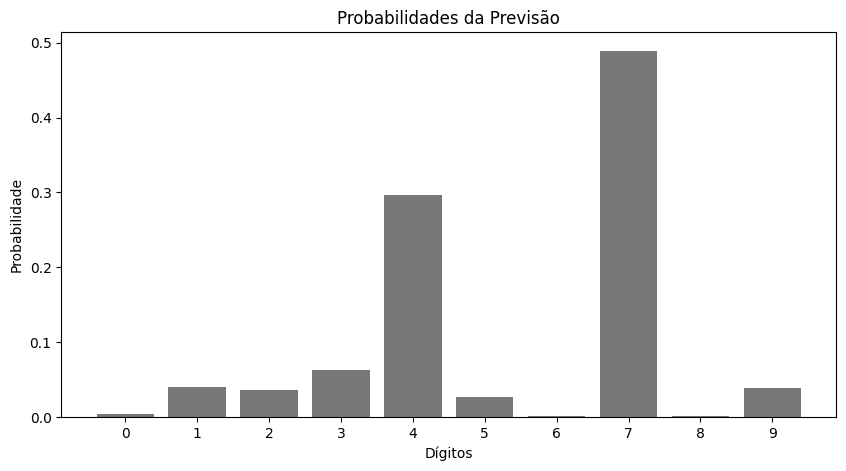

In [19]:
# Faz a previsão com o modelo treinado
prediction = model.predict(img_final)

# Pega o dígito com a maior probabilidade
predicted_digit = np.argmax(prediction)

print(f"\nO modelo previu que este número é: {predicted_digit}")

# (Opcional) Mostra as probabilidades para cada dígito
plt.figure(figsize=(10,5))
plt.bar(range(10), prediction[0], color="#777777")
plt.xticks(range(10))
plt.title("Probabilidades da Previsão")
plt.xlabel("Dígitos")
plt.ylabel("Probabilidade")
plt.show()

# Projeto de Deep Learning: Classificador de Dígitos Manuscritos com MNIST

**Autor:** Maiquel
**Data:** 17 de julho de 2025
**Local:** Joinville, SC, Brasil

---

## 1. Objetivo do Projeto

O objetivo principal deste projeto é desenvolver e treinar um modelo de **Deep Learning** utilizando uma rede neural artificial, capaz de reconhecer e classificar corretamente dígitos de 0 a 9 a partir de imagens de números escritos à mão.

Este projeto serve como uma introdução fundamental e prática aos conceitos de **Visão Computacional** e à construção de modelos de classificação, sendo amplamente conhecido como o "Olá, Mundo!" do Deep Learning.

---

## 2. Dataset Utilizado

Utilizamos o famoso dataset **MNIST** (Modified National Institute of Standards and Technology). Ele é um dos conjuntos de dados mais clássicos e bem estudados na área de aprendizado de máquina.

* **Conteúdo:** 70.000 imagens em tons de cinza de dígitos manuscritos.
* **Divisão:** 60.000 imagens para o conjunto de **treinamento** e 10.000 para o conjunto de **teste**.
* **Formato das Imagens:** 28x28 pixels.

---

## 3. Tecnologias e Ferramentas

* **Linguagem:** Python 3
* **Plataforma:** Google Colaboratory (Colab)
* **Bibliotecas Principais:**
    * **TensorFlow e Keras:** Para a construção, compilação e treinamento da rede neural.
    * **NumPy:** Para manipulação eficiente dos arrays de dados.
    * **Matplotlib:** Para a visualização dos dados e dos resultados.
    * **Pillow (PIL):** Para o processamento de imagens externas fornecidas pelo usuário.

---

## 4. Metodologia e Passos

O projeto foi estruturado seguindo os seguintes passos:

1.  **Importação das Bibliotecas:** Carregamento de todas as ferramentas necessárias.
2.  **Carregamento e Exploração dos Dados:** Download do dataset MNIST e visualização de exemplos.
3.  **Pré-processamento:** Normalização dos valores dos pixels das imagens para o intervalo [0, 1], preparando-os para a rede neural.
4.  **Construção do Modelo:** Definição da arquitetura da rede neural sequencial com camadas `Flatten` e `Dense`.
5.  **Compilação e Treinamento:** Configuração do otimizador (`adam`), da função de perda (`loss`) e início do processo de treinamento com o método `fit()`.
6.  **Avaliação de Performance:** Verificação da acurácia do modelo utilizando o conjunto de teste, que contém dados inéditos.
7.  **Teste Interativo:** Implementação de uma função para que o usuário possa fazer o upload de sua própria imagem de um dígito e receber a previsão do modelo em tempo real.